In [7]:
from astropy.table import Table
from astropy.constants import c
from astropy import units as u

import numpy as np

from tqdm import tqdm

from scipy.optimize import minimize

import sys
sys.path.append('..')

from get_cutouts import get_cutout

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


In [8]:
loa_table = Table.read('/pscratch/sd/d/dbustos/Fall_26/loa_rot_velocity.fits')

loa_table[:5]

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_RR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,VI,deproj_dist,deproj_r26,manual_VI,rot_vel_filing,r_kpc,chi2_reduced,vmax_fit,rturn_fit,vmax_err,rturn_err
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64
169678387281926,1430874,257.7495971,56.9324928,0.028921517883227336,0.028921517883227336,0,121857.89663615823,0.003250448915035935,0.31250071154567677,6.557606220245361,206.22810010342067,199.6704938831753,1,2.4024789259983957e-05,3.0,182.8750198451699,11.489101308260244,2.401212431981059e-05,0,0.008096415535868652,0.7783957484224773,0,0,0.20122416188287864,0.38706405138543304,188.0016333989227,0.004035780336833629,145.11961827963177,4.09983872988525
243323033878571,631434,151.0147419137485,1.6331543609904198,1.3809988331159857,1.3809988331159857,4,0.7242707014083862,0.0057124407591539585,0.9175586924842383,51.69132614135742,32.48938717521324,19.201938966144183,1,5.5595100500533275e-05,12.0,472239.65646196203,24.11477245431036,1.7258340278094598e-05,0,0.006601088916040368,1.0602974753074295,0,0,0.26035704174416274,--,--,--,145.11961827963177,4.09983872988525
1004815400304641,188925,193.6701,28.93758,0.0082724267277799,0.0082724267277799,0,20781.262633197082,0.0009923137447555642,0.026284859154548004,48.5860481262207,146.26021571620655,97.67416758998584,2,2.3542643581428787e-05,25.0,-181.63274387448345,72.81809787647651,1.6648346838273807e-05,0,0.0011151277859353821,0.02953801350383857,0,0,0.008088028889852567,5.63436883524322,170.25925589571688,0.03525810913705583,145.11961827963177,4.09983872988525
1005093910478848,1309576,234.30175,43.3014166667,0.019607169071382585,0.019607169071382585,0,21025.242969959974,0.004020441905483598,0.2179634595949638,134.6117401123047,320.7967839323471,186.18504382004244,1,2.380730399661915e-05,7.0,173.70559603525007,12.904304444072334,2.3796769180937358e-05,0,0.005374691904048404,0.2913825069989467,0,0,0.08955195966842268,1.3727806283237154,171.17940047936136,0.040082806353557265,145.11961827963177,4.09983872988525
1005093910478849,1309576,234.303916667,43.2961944444,0.0190429075748926,0.0190429075748926,0,37842.76546475291,0.0023170693385198464,0.12561714881549862,134.6117401123047,204.59833750241611,69.98659739011143,1,2.3794128780331918e-05,7.0,-126.47090634603123,37.70665102866408,2.3796769180937358e-05,0,0.0031473131687750006,0.1706278271946506,0,0,0.05243985459735577,1.3727806283237154,171.17940047936136,0.040082806353557265,145.11961827963177,4.09983872988525


In [9]:
SGA = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')

SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

In [10]:
loa_table[loa_table['SGA_ID']==608015][:10]

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_RR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,VI,deproj_dist,deproj_r26,manual_VI,rot_vel_filing,r_kpc,chi2_reduced,vmax_fit,rturn_fit,vmax_err,rturn_err
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64
1070235180335104,608015,209.00663988401783,4.958714076562137,1.5320474110690858,1.5320474110690858,4,1.1759424209594727,0.07092509342702036,1.0000000102908122,37.58530807495117,217.58530684137438,0.0,1,5.912200725704581e-05,93.0,584564.0711332676,24.809428075999296,9.572184979567734e-06,0,0.07092509342702036,1.0000000102908122,0,0,0.2557658763359926,--,--,--,145.11961827963177,4.09983872988525
1070235180335105,608015,209.02096855530698,4.977262285695551,1.2794394208547095,1.2794394208547095,4,3.3990245014429092,0.04751981259609086,0.6700000068946639,37.58530807495117,217.58530684139075,0.0,1,5.3223740358348055e-05,93.0,487916.25103598967,22.03990529273885,9.572184979567734e-06,0,0.04751981259609086,0.6700000068946639,0,0,0.17136313713166978,--,--,--,145.11961827963177,4.09983872988525
1070235184529408,608015,209.093492769661,5.07112269091585,-0.00199569129234795,4.13114935733491e-48,1570,1.94266889222573e+84,0.07092509342667842,1.000000010285991,37.58530807495117,37.585306841235095,0.0,1,2.330288829665476e-05,93.0,-2360.838299229996,9.513361958800491,9.572184979567734e-06,0,0.07092509342667842,1.000000010285991,0,0,0.2557658763347596,--,--,--,145.11961827963177,4.09983872988525
1079031273357335,608015,209.02267226373428,5.024157016567969,0.004144553103648936,0.004144553103648936,0,251.70684415989672,0.02880646471418274,0.4061533600976583,37.58530807495117,288.7042908342138,251.11898275926262,1,2.3446259851292e-05,93.0,-35.78670578361594,25.40765358264927,9.572184979567734e-06,0,0.02975105203690849,0.41947145792178414,0,0,0.10728648391669279,46.94329265811507,169.1243947593655,0.02311901264278514,145.11961827963177,4.09983872988525
1079031273357358,608015,209.03025827160056,4.9633483407865775,0.004534916150348183,0.004534916150348183,0,5929.879994997755,0.05521649854089451,0.7785185248424541,37.58530807495117,200.935809221877,163.35050114692584,1,2.3455374628044974e-05,93.0,143.80098494436555,10.045581635445208,9.572184979567734e-06,0,0.055223018041498255,0.7786104457741839,0,0,0.19914198092733348,46.94329265811507,169.1243947593655,0.02311901264278514,145.11961827963177,4.09983872988525
1079031277551616,608015,209.0991262705701,5.027887617405946,0.33028632713220824,0.33028632713220824,0,241.8007052540779,0.05056645628749437,0.7129558011776965,37.58530807495117,75.13829374188298,37.552985666931804,1,3.106150285450296e-05,93.0,157381.2239954115,16.219787667730106,9.572184979567734e-06,0,0.05139416918301456,0.7246260417659548,0,0,0.18533461266841897,--,--,--,145.11961827963177,4.09983872988525
1079031277551621,608015,209.08247288120626,4.9873607129416095,0.5907851106314281,0.5907851106314281,0,9.369052816182375,0.04244936327063532,0.5985098031792199,37.58530807495117,130.48163263542605,92.89632456047488,1,3.714401572577252e-05,93.0,4441759.486223137,304.6979470823881,9.572184979567734e-06,0,0.06689063926019925,0.9431166984275681,0,0,0.24121706637433266,--,--,--,145.11961827963177,4.09983872988525
1083429319868416,608015,209.00663988401783,4.958714076562137,0.2661229712102673,0.2661229712102673,4,3.37805313244462,0.07092509342702036,1.0000000102908122,37.58530807495117,217.58530684137438,0.0,1,2.956332143109441e-05,93.0,100221.36520226795,12.255439828708045,9.572184979567734e-06,0,0.07092509342702036,1.0000000102908122,0,0,0.2557658763359926,--,--,--,145.11961827963177,4.09983872988525
1083429319868417,608015,209.02096855530698,4.977262285695551,0.00455249048223364,0.00455249048223364,0,160.40359472711134,0.04751981259609086,0.6700000068946639,37.

In [21]:
# def deprojection(params, ra, dec):
#     '''
#     fit using alpha
#     '''
#     ra_cen, dec_cen, PA, v_max, r_turn, vsys, a = params

#     # gets distance from center in degrees instead of radius
#     dep_ra = (ra - ra_cen) * np.cos(np.radians(dec))

#     dep_dec = (dec - dec_cen)

#     #rotate semimajor axis
#     r = dep_ra * np.cos(np.radians(PA)) + dep_dec * np.sin(np.radians(PA)) # units degrees

#     # model to fit to
#     v_model = vsys + (v_max * r) / ((r_turn**a + r**a)**(1/a))

#     return v_model

In [22]:
# def chi2(params, ra, dec, v_data, v_err):
#     '''
#     add comments
#     '''
#     ra_cen, dec_cen, PA, v_max, r_turn, vsys, a = params
    
#     v_model = deprojection(params, ra, dec)
    
#     return np.sum(((v_data-v_model)/v_err)**2)

In [26]:
def deprojection(params, ra, dec, D26):
    '''
    add comments
    '''
    ra_cen, dec_cen, PA, v_max, r_turn, vsys = params

    # gets distance from center in degrees instead of radius
    dep_ra = (ra - ra_cen) * np.cos(np.radians(dec))

    dep_dec = (dec - dec_cen)

    #rotate semimajor axis
    r_deg = dep_ra * np.cos(np.radians(PA)) + dep_dec * np.sin(np.radians(PA)) # units degrees

    # diameter to radius (in arcmin) to degrees
    r26_deg = D26/120 # units degrees

    r = r_deg/r26_deg # units r26

    # model to fit to
    v_model = vsys + (v_max) * np.tanh(r/r_turn)

    return v_model

In [27]:
def chi2(params, ra, dec, v_data, v_err):
    '''
    add comments
    '''
    ra_cen, dec_cen, PA, v_max, r_turn, vsys = params
    
    v_model = deprojection(params, ra, dec, d26)
    
    return np.sum(((v_data-v_model)/v_err)**2)

In [28]:
# get r_turn from coordinates of vmax instead of radius distance
def r_turn(ra, dec, ra_cen, dec_cen, D26):
    '''
    ra & dec where max velocity is
    '''
    
    # gets distance from center in degrees instead of radius
    max_ra = (ra - ra_cen) * np.cos(np.radians(dec))
    max_dec = (dec - dec_cen)

    r_deg = np.sqrt(max_ra**2 + max_dec**2)

    r26_deg = D26/120 # units degrees

    rturn = r_deg/r26_deg # units r26

    return rturn

In [29]:
test_galaxy = loa_table[(loa_table['SGA_ID']==608015) & (abs(loa_table['Velocity'])<1000)]

# sga information corresponding to galaxy
SGA_inf = SGA[SGA_dict[608015]]

# list of ra and dec of fibers in galaxy
ra, dec = (np.array(test_galaxy['TARGET_RA']), np.array(test_galaxy['TARGET_DEC']))\

d26 = SGA_inf['D26']

velocity = test_galaxy['Velocity']

v_err = test_galaxy['V_err']

idx = np.argmax(abs(velocity))

#-----------------
# initial guesses
#-----------------

# ra, dec, PA, center of galaxy
ra0_in = SGA_inf['RA']
dec0_in = SGA_inf['DEC']
PA_in = SGA_inf['PA']

# max velocity in galaxy
vmax_in = velocity[idx]

# use r_turn fxn to get initial guess for rturn
# based off coordinates of vmax
rturn_in = r_turn(ra[idx], dec[idx], ra0_in, dec0_in, d26)

# systemic velocity = z_cen * c
# vsys_in = SGA_inf['Z_LEDA'] * c.value
vsys_in = test_galaxy['Z_center'][0] * c.value

alpha_in = 2

initial_guess = [ra0_in, dec0_in, PA_in, vmax_in, rturn_in, vsys_in]
# initial_guess = [ra0_in, dec0_in, PA_in, vmax_in, rturn_in, vsys_in, alpha_in]


# set bounds
ra_bounds = (np.min(ra), np.max(ra))
dec_bounds = (np.min(dec), np.max(dec))
PA_bounds = (-180,180)
vmax_bounds = (0,1000)
rturn_bounds = (0.001, rturn_in*10)
vsys_bounds = (np.min(velocity), np.max(velocity))
alpha_bounds = (0.001,5)

bounds = [ra_bounds, dec_bounds, PA_bounds, vmax_bounds, rturn_bounds, vsys_bounds]
# bounds = [ra_bounds, dec_bounds, PA_bounds, vmax_bounds, rturn_bounds, vsys_bounds, alpha_bounds]

minimizer = minimize(fun = chi2,
                     x0 = initial_guess,
                     args = (ra, dec, velocity, v_err),
                     bounds = bounds,
                     method = 'Powell')

min_fits = minimizer.x

print(min_fits)

/tmp/ipykernel_1984115/2959482242.py:55: OptimizeWarning: Initial guess is not within the specified bounds
  minimizer = minimize(fun = chi2,


[ 209.06785475    4.96308682 -142.84982922  419.99503348    0.88505609
   90.56139565]


create a linspace of ra and dec, and use calculate best fit at

In [ ]:
ra_range = np.linspace(np.min(ra), np.max(ra), 365)
dec_range = np.linspace(np.min(dec), np.max(dec), 365)

RA_grid, DEC_grid = np.meshgrid(ra_range, dec_range)

velocity_fit = deprojection(min_fits, RA_grid, DEC_grid, D26)

In [ ]:
for test in range(1):

    sga_id = 608015
    
    #identify all targets in the galaxy
    targ_list = test_galaxy

    #find the index for this target in SGA
    sga_idx = SGA_dict[sga_id]
    
    #get coordinates for center of galaxy
    center_ra, center_dec = float(SGA['RA'][sga_idx]), float(SGA['DEC'][sga_idx])

    #get velocities for each point
    velocity = np.array(velocity_fit)

    #find max velocity for colormap
    v_max = max((v for v in abs(velocity.flatten()) if v<=1000), default=1000)

#-------------------------------------------
# get cutout
#-------------------------------------------
    # D26 in arcmin
    d26 = SGA['D26'][sga_idx]
    
    pix = int(2 * d26*60/0.262)

    if (pix < 2500):
        npix = np.minimum(pix,1024)

    elif (pix > 2500):
        npix = np.minimum(pix,3000)

    img_file, wcs = get_cutout(sga_id, center_ra, center_dec, dir='/pscratch/sd/d/dbustos/loa_cutouts/cutouts/',dr=10,size=npix)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))


    ax = fig1.add_subplot(111, projection=wcs)
    
    #add the cutout to make ellipse right size, but set opacity to 0
    ax.imshow(np.flip(img, axis=0),alpha=0)
    ax.coords[0].set_format_unit(u.deg)
    ax.set(xlabel='ra', ylabel='dec')
#---------------------------------
# generate ellipse
#---------------------------------
    
    #PA for ellipse in rad
    PA = np.radians(SGA['PA'][sga_idx])
    PA_deg = SGA['PA'][sga_idx]
    
    #radius semimajor axis in arcmin
    smajor = (d26/2)/60
    #radius semiminor axis in arcmin
    sminor = ((SGA['BA'][sga_idx]) * smajor)

    theta = np.linspace(0,2*np.pi,365)
    # ellipse coordinates before transformation
    smajor1 = smajor * np.cos(theta)
    sminor1 = sminor * np.sin(theta)

    # rotation matrix
    rot_ra = (smajor1*np.sin(PA) + sminor1*np.cos(PA))/np.cos(np.radians(center_dec))
    rot_dec = smajor1*np.cos(PA) - sminor1*np.sin(PA)
 
    #ellipse coordinates after transformation
    ellipse_ra = center_ra + rot_ra
    ellipse_dec = center_dec + rot_dec

    ax.plot(ellipse_ra,ellipse_dec,color = 'black',lw=2,transform= ax.get_transform('icrs'))

#-----------------------------------------------------
# filter out ra and dec to only take those in ellipse
#-----------------------------------------------------

    ra_range = np.linspace(np.min(ellipse_ra), np.max(ellipse_ra), 365)
    dec_range = np.linspace(np.min(ellipse_dec), np.max(ellipse_dec), 365)

    RA_grid, DEC_grid = np.meshgrid(ra_range, dec_range)

    velocity_fit = deprojection(min_fits, RA_grid, DEC_grid, D26)
    
    
    dra = (RA_grid - center_ra) * np.cos(np.radians(center_dec))
    ddec = DEC_grid - center_dec

    proj_major = dra * np.sin(PA) + ddec * np.cos(PA)
    proj_minor = dra * np.cos(PA) - ddec * np.sin(PA)

    inside_ellipse_mask = ((proj_major / smajor)**2 + (proj_minor / sminor)**2) < .9
    # inside_ellipse_mask = ((dra / smajor)**2 + (ddec / sminor)**2) < .9
    
    # velocity mask
    velocity_2d = velocity.reshape(365, 365) if velocity.ndim == 1 else velocity
    valid_points = inside_ellipse_mask & (abs(velocity_2d) < 1000)

    ra_new = RA_grid[valid_points]
    dec_new = DEC_grid[valid_points]
    c_values = velocity_2d[valid_points]
    

# #-------------------------------------------
# # plot ra and dec
# #-------------------------------------------

    ax1 = ax.scatter(np.array(ra_new), np.array(dec_new),
                     vmax = v_max, vmin= -v_max,
                     c = c_values, cmap = 'bwr',transform= ax.get_transform('icrs'))
    
    
    fig1.colorbar(ax1, ax=ax)
    
    ax.set_title('best fit - SGA ID: {}'.format(sga_id))
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    # fig1.savefig('/pscratch/sd/d/dbustos/vel_maps/' + 'sga_{}_velocity_map.png'.format(sga_id), dpi=120)
    
    # fig1.clear()
    # plt.close(fig1)

In [ ]:
# dont delete below

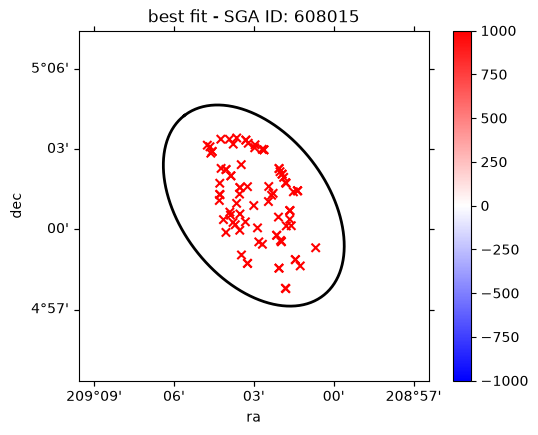

In [83]:
for test in range(1):

    sga_id = 608015
    
    #identify all targets in the galaxy
    targ_list = test_galaxy

    #find the index for this target in SGA
    sga_idx = SGA_dict[sga_id]
    
    #get coordinates for center of galaxy
    center_ra, center_dec = float(SGA['RA'][sga_idx]), float(SGA['DEC'][sga_idx])

    #get velocities for each point
    velocity = np.array(velocity_fit)

    #find max velocity for colormap
    v_max = max((v for v in abs(velocity) if v<=1000), default=1000)

#-------------------------------------------
# get cutout
#-------------------------------------------
    # D26 in arcmin
    d26 = SGA['D26'][sga_idx]
    
    pix = int(2 * d26*60/0.262)

    if (pix < 2500):
        npix = np.minimum(pix,1024)

    elif (pix > 2500):
        npix = np.minimum(pix,3000)

    img_file, wcs = get_cutout(sga_id, center_ra, center_dec, dir='/pscratch/sd/d/dbustos/loa_cutouts/cutouts/',dr=10,size=npix)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))


    ax = fig1.add_subplot(111, projection=wcs)
    
    #add the cutout to make ellipse right size, but set opacity to 0
    ax.imshow(np.flip(img, axis=0),alpha=0)
    ax.coords[0].set_format_unit(u.deg)
    ax.set(xlabel='ra', ylabel='dec')
#---------------------------------
# generate ellipse
#---------------------------------
    
    #PA for ellipse in rad
    PA = np.radians(SGA['PA'][sga_idx])
    
    #radius semimajor axis in arcmin
    smajor = (d26/2)/60
    #radius semiminor axis in arcmin
    sminor = ((SGA['BA'][sga_idx]) * smajor)

    theta = np.linspace(0,2*np.pi,365)
    # ellipse coordinates before transformation
    smajor1 = smajor * np.cos(theta)
    sminor1 = sminor * np.sin(theta)

    # rotation matrix
    rot_ra = (smajor1*np.sin(PA) + sminor1*np.cos(PA))/np.cos(np.radians(center_dec))
    rot_dec = smajor1*np.cos(PA) - sminor1*np.sin(PA)
 
    #ellipse coordinates after transformation
    ellipse_ra = center_ra + rot_ra
    ellipse_dec = center_dec + rot_dec

    ax.plot(ellipse_ra,ellipse_dec,color = 'black',lw=2,transform= ax.get_transform('icrs'))

#----------------------------
    # pa_minor = PA + np.pi/2

    # minor_line = np.array([-sminor, sminor])

    # # rotation matrix
    # rot_line_ra = minor_line * np.sin(pa_minor) / np.cos(np.radians(center_dec))
    # rot_line_dec = minor_line * np.cos(pa_minor)

    # minor_line_ra = center_ra + rot_line_ra 

    # minor_line_dec = center_dec + rot_line_dec 

    # ax.plot(minor_line_ra, minor_line_dec,color = 'black',lw=2,ls = ':',alpha = .5,transform= ax.get_transform('icrs'))
#-------------------------------------------
# get ra and dec
#-------------------------------------------
    # velocities < 1000 km/s
    ra = np.array(targ_list['TARGET_RA'][velocity<1000]) 
    dec = np.array(targ_list['TARGET_DEC'][velocity<1000]) 

    # velocities < 1000 km/s
    ra_null = np.array(targ_list['TARGET_RA'][velocity>1000]) 
    dec_null = np.array(targ_list['TARGET_DEC'][velocity>1000]) 

#-------------------------------------------
# plot ra and dec
#-------------------------------------------

    ax1 = ax.scatter(np.array(ra), np.array(dec),
                     vmax = v_max, vmin= -v_max,
                     c = velocity[velocity < 1000], cmap = 'bwr', edgecolor = 'black',transform= ax.get_transform('icrs'))

    ax2 = ax.scatter(np.array(ra_null), np.array(dec_null),
                     vmax = v_max, vmin= -v_max,
                     c = velocity[velocity > 1000], cmap = 'bwr', marker = 'x',transform= ax.get_transform('icrs'))
    
    fig1.colorbar(ax1, ax=ax)
    
    ax.set_title('best fit - SGA ID: {}'.format(sga_id))
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    # fig1.savefig('/pscratch/sd/d/dbustos/vel_maps/' + 'sga_{}_velocity_map.png'.format(sga_id), dpi=120)
    
    # fig1.clear()
    # plt.close(fig1)

In [81]:
velocity_fit = deprojection(min_fits, ra, dec, d26, center_ra, center_dec, PA_deg, vsys)

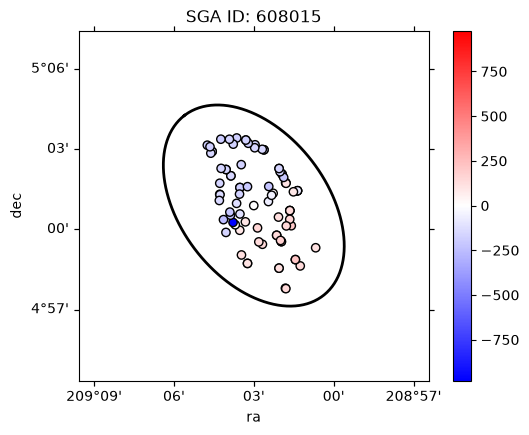

In [82]:
for test in range(1):

    sga_id = 608015
    
    #identify all targets in the galaxy
    targ_list = test_galaxy

    #find the index for this target in SGA
    sga_idx = SGA_dict[sga_id]
    
    #get coordinates for center of galaxy
    center_ra, center_dec = float(SGA['RA'][sga_idx]), float(SGA['DEC'][sga_idx])

    #get velocities for each point
    velocity = np.array(targ_list['Velocity'])

    #find max velocity for colormap
    v_max = max((v for v in abs(velocity) if v<=1000), default=1000)

#-------------------------------------------
# get cutout
#-------------------------------------------
    # D26 in arcmin
    d26 = SGA['D26'][sga_idx]
    
    pix = int(2 * d26*60/0.262)

    if (pix < 2500):
        npix = np.minimum(pix,1024)

    elif (pix > 2500):
        npix = np.minimum(pix,3000)

    img_file, wcs = get_cutout(sga_id, center_ra, center_dec, dir='/pscratch/sd/d/dbustos/loa_cutouts/cutouts/',dr=10,size=npix)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))


    ax = fig1.add_subplot(111, projection=wcs)
    
    #add the cutout to make ellipse right size, but set opacity to 0
    ax.imshow(np.flip(img, axis=0),alpha=0)
    ax.coords[0].set_format_unit(u.deg)
    ax.set(xlabel='ra', ylabel='dec')
#---------------------------------
# generate ellipse
#---------------------------------
    
    #PA for ellipse in rad
    PA = np.radians(SGA['PA'][sga_idx])
    
    #radius semimajor axis in arcmin
    smajor = (d26/2)/60
    #radius semiminor axis in arcmin
    sminor = ((SGA['BA'][sga_idx]) * smajor)

    theta = np.linspace(0,2*np.pi,365)
    # ellipse coordinates before transformation
    smajor1 = smajor * np.cos(theta)
    sminor1 = sminor * np.sin(theta)

    # rotation matrix
    rot_ra = (smajor1*np.sin(PA) + sminor1*np.cos(PA))/np.cos(np.radians(center_dec))
    rot_dec = smajor1*np.cos(PA) - sminor1*np.sin(PA)
 
    #ellipse coordinates after transformation
    ellipse_ra = center_ra + rot_ra
    ellipse_dec = center_dec + rot_dec

    ax.plot(ellipse_ra,ellipse_dec,color = 'black',lw=2,transform= ax.get_transform('icrs'))

#----------------------------
    # pa_minor = PA + np.pi/2

    # minor_line = np.array([-sminor, sminor])

    # # rotation matrix
    # rot_line_ra = minor_line * np.sin(pa_minor) / np.cos(np.radians(center_dec))
    # rot_line_dec = minor_line * np.cos(pa_minor)

    # minor_line_ra = center_ra + rot_line_ra 

    # minor_line_dec = center_dec + rot_line_dec 

    # ax.plot(minor_line_ra, minor_line_dec,color = 'black',lw=2,ls = ':',alpha = .5,transform= ax.get_transform('icrs'))
#-------------------------------------------
# get ra and dec
#-------------------------------------------
    # velocities < 1000 km/s
    ra = np.array(targ_list['TARGET_RA'][velocity<1000]) 
    dec = np.array(targ_list['TARGET_DEC'][velocity<1000]) 

    # velocities < 1000 km/s
    ra_null = np.array(targ_list['TARGET_RA'][velocity>1000]) 
    dec_null = np.array(targ_list['TARGET_DEC'][velocity>1000]) 

#-------------------------------------------
# plot ra and dec
#-------------------------------------------

    ax1 = ax.scatter(np.array(ra), np.array(dec),
                     vmax = v_max, vmin= -v_max,
                     c = velocity[velocity < 1000], cmap = 'bwr', edgecolor = 'black',transform= ax.get_transform('icrs'))

    ax2 = ax.scatter(np.array(ra_null), np.array(dec_null),
                     vmax = v_max, vmin= -v_max,
                     c = velocity[velocity > 1000], cmap = 'bwr', marker = 'x',transform= ax.get_transform('icrs'))
    
    fig1.colorbar(ax1, ax=ax)
    
#-------------------------
# plot indices to fibers
#-------------------------
    # loc_idx = {}
    
    # for i, j in enumerate(targ_list):
    #     ra, dec = j['TARGET_RA'], j['TARGET_DEC']

    #     if (ra, dec) not in loc_idx:
    #         loc_idx[(ra,dec)] = []

    #     loc_idx[(ra,dec)].append(str(i))

    # for i, j in loc_idx.items():
    #     combined = ', '.join(loc_idx[i])
    #     ax.text(i[0], i[1], combined, transform=ax.get_transform('icrs'), color='yellow', fontsize=7, fontweight = 'bold'
    #            ,bbox = dict(facecolor='black', alpha=0.5, edgecolor='white', lw=0.01, pad = .5))

    
    # # note the galaxy still needs manual VI
    # if targ_list['manual_VI'][0] == 1:
    #     ax.annotate('needs VI again', xy = (10,10), xycoords = 'figure pixels')
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    # fig1.savefig('/pscratch/sd/d/dbustos/vel_maps/' + 'sga_{}_velocity_map.png'.format(sga_id), dpi=120)
    
    # fig1.clear()
    # plt.close(fig1)